## Model Training pipeline

In [145]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import optuna
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.metrics import log_loss, confusion_matrix, classification_report, f1_score, precision_score, average_precision_score
from typing import Any, Dict, List


## Loading the Datasets

In [122]:
features_path = "../data/"

In [140]:
X_train = pd.read_csv(features_path+ "X_train_transformed.csv")
y_train = pd.read_csv(features_path+ "y_train.csv")

X_test = pd.read_csv(features_path+ "X_test_transformed.csv")
y_test = pd.read_csv(features_path+ "y_test.csv")

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(4928, 30)
(4928, 1)
(1410, 30)
(1410, 1)


In [196]:
X_train.columns

Index(['NUM__SENIORCITIZEN', 'NUM__TENURE', 'NUM__MONTHLYCHARGES',
       'NUM__TOTALCHARGES', 'CAT__GENDER_MALE', 'CAT__PARTNER_YES',
       'CAT__DEPENDENTS_YES', 'CAT__PHONESERVICE_YES',
       'CAT__MULTIPLELINES_NO_PHONE_SERVICE', 'CAT__MULTIPLELINES_YES',
       'CAT__INTERNETSERVICE_FIBER_OPTIC', 'CAT__INTERNETSERVICE_NO',
       'CAT__ONLINESECURITY_NO_INTERNET_SERVICE', 'CAT__ONLINESECURITY_YES',
       'CAT__ONLINEBACKUP_NO_INTERNET_SERVICE', 'CAT__ONLINEBACKUP_YES',
       'CAT__DEVICEPROTECTION_NO_INTERNET_SERVICE',
       'CAT__DEVICEPROTECTION_YES', 'CAT__TECHSUPPORT_NO_INTERNET_SERVICE',
       'CAT__TECHSUPPORT_YES', 'CAT__STREAMINGTV_NO_INTERNET_SERVICE',
       'CAT__STREAMINGTV_YES', 'CAT__STREAMINGMOVIES_NO_INTERNET_SERVICE',
       'CAT__STREAMINGMOVIES_YES', 'CAT__CONTRACT_ONE_YEAR',
       'CAT__CONTRACT_TWO_YEAR', 'CAT__PAPERLESSBILLING_YES',
       'CAT__PAYMENTMETHOD_CREDIT_CARD', 'CAT__PAYMENTMETHOD_ELECTRONIC_CHECK',
       'CAT__PAYMENTMETHOD_MAILED_CHECK']

In [141]:
y_train.value_counts()


0
0    3630
1    1298
Name: count, dtype: int64

In [142]:
X_train.describe()

,NUM__SENIORCITIZEN,NUM__TENURE,NUM__MONTHLYCHARGES,NUM__TOTALCHARGES,CAT__GENDER_MALE,CAT__PARTNER_YES,CAT__DEPENDENTS_YES,CAT__PHONESERVICE_YES,CAT__MULTIPLELINES_NO_PHONE_SERVICE,CAT__MULTIPLELINES_YES,...,CAT__STREAMINGTV_NO_INTERNET_SERVICE,CAT__STREAMINGTV_YES,CAT__STREAMINGMOVIES_NO_INTERNET_SERVICE,CAT__STREAMINGMOVIES_YES,CAT__CONTRACT_ONE_YEAR,CAT__CONTRACT_TWO_YEAR,CAT__PAPERLESSBILLING_YES,CAT__PAYMENTMETHOD_CREDIT_CARD,CAT__PAYMENTMETHOD_ELECTRONIC_CHECK,CAT__PAYMENTMETHOD_MAILED_CHECK
count,4.928000e+03,4.928000e+03,4.928000e+03,4.928000e+03,4928.000000,4928.000000,4928.000000,4928.000000,4928.000000,4928.000000,...,4928.000000,4928.000000,4928.000000,4928.000000,4928.000000,4928.000000,4928.000000,4928.000000,4928.000000,4928.000000
mean,-1.658125e-17,-6.920871e-17,-8.651089e-17,-1.182315e-16,0.509334,0.484375,0.300325,0.900365,0.099635,0.418222,...,0.224026,0.379870,0.224026,0.382508,0.210836,0.237825,0.593141,0.209213,0.335024,0.235998
std,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,0.499964,0.499807,0.458446,0.299543,0.299543,0.493317,...,0.416982,0.485404,0.416982,0.486049,0.407944,0.425794,0.491298,0.406788,0.472047,0.424664
min,-4.362776e-01,-1.312226e+00,-1.519764e+00,-9.959418e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-4.362776e-01,-9.452221e-01,-1.011670e+00,-8.310168e-01,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-4.362776e-01,-1.296578e-01,1.948454e-01,-3.878485e-01,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,-4.362776e-01,9.305757e-01,8.436166e-01,6.462148e-01,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,2.292118e+00,1.623805e+00,1.806843e+00,2.851204e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Tune hyperparameters using Optuna

In [162]:
def create_objective(X:pd.DataFrame,y:pd.DataFrame,n_splits:int, parameter_search_space:Dict[str,Any], scoring_func) -> float:
    """Wrapper function for objective to pass the required datasets and other parameters for hyperparameter tuning."""

    def tune_hyperparameters_objective(trial):
        """ Objective function for tuning the parameters with optuna with early stopping."""

        ## Basic parameters dict
        params = {}


        # Parse and add params from parameter_search_space
        for name, distribution in parameter_search_space.items():
            params[name] = trial._suggest(name, distribution)


        # Stratified Cross Validation
        cv = StratifiedKFold(n_splits = n_splits, shuffle = True, random_state = 30)
        kfold_scores = []
        kfold_best_n_estimator = []


        # Loop through the k folds and keep each one as validation
        for train_idx,val_idx in cv.split(X, y):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
            # Early stopping on validation set
            xgb_model = XGBClassifier(**params, n_estimators = 300, early_stopping_rounds=50)
            xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

            # Extract predictions
            y_preds = xgb_model.predict(X_val)
            y_probs = xgb_model.predict_proba(X_val)

            # Extract score 
            score = scoring_func(y_val, y_preds, y_probs)

            # Extract and store best iteration (number of trees)
            kfold_best_n_estimator.append(xgb_model.best_iteration)

            # Add scores to list
            kfold_scores.append(score)

        # Extract and store the best iteration in memory
        trial.set_user_attr("n_estimators", int(np.mean(kfold_best_n_estimator)))
        return np.mean(kfold_scores)

    return tune_hyperparameters_objective



In [163]:
METRIC_REGISTRY = {
    "macro_f1": lambda y_true, y_pred, y_prob: f1_score(y_true, y_pred, average='macro'),
    "pr_auc": lambda y_true, y_pred, y_prob: average_precision_score(y_true, y_prob)
}

In [180]:

# Define your parameter distributions explicitly as objects
parameter_search_space = {
    "objective": optuna.distributions.CategoricalDistribution(["binary:logistic"]), 
    "eval_metric": optuna.distributions.CategoricalDistribution(["logloss"]),
    "scale_pos_weight":optuna.distributions.CategoricalDistribution([1.7]), # sqrt(negatives/positives)
    "learning_rate": optuna.distributions.FloatDistribution(0.01, 0.3, log=True),
    "max_depth": optuna.distributions.IntDistribution(4, 10),
    "min_child_weight": optuna.distributions.IntDistribution(3, 8),
    "subsample": optuna.distributions.FloatDistribution(0.7, 1.0),
    "colsample_bytree": optuna.distributions.FloatDistribution(0.7, 1.0),
    "reg_alpha": optuna.distributions.FloatDistribution(1e-8, 3.0, log=True),
    "reg_lambda": optuna.distributions.FloatDistribution(1, 3.0, log=True),

}


In [181]:
# Create the objective function
custom_objective = create_objective(
    X=X_train, 
    y=y_train, 
    n_splits=5, 
    parameter_search_space=parameter_search_space,
    scoring_func= METRIC_REGISTRY["macro_f1"]
)

# Use Optuna for hyperparameter tuning
study = optuna.create_study(direction="maximize")
study.optimize(custom_objective, n_trials=30)

best_tuned_parameters = study.best_params
print("Best Hyperparamters :", best_tuned_parameters)

best_n_estimators = study.best_trial.user_attrs["n_estimators"]
print("Ideal n_estimators:", best_n_estimators)


[I 2026-07-23 02:45:55,241] A new study created in memory with name: no-name-ea8d4a94-6809-4a84-a2a4-860ef331b821


[I 2026-07-23 02:45:55,731] Trial 0 finished with value: 0.7517326375389344 and parameters: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': 1.7, 'learning_rate': 0.2897719964110345, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.8488828063423813, 'colsample_bytree': 0.8487224635818721, 'reg_alpha': 1.9569441428632754, 'reg_lambda': 2.031271632609222}. Best is trial 0 with value: 0.7517326375389344.
[I 2026-07-23 02:45:57,696] Trial 1 finished with value: 0.7466409502374869 and parameters: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': 1.7, 'learning_rate': 0.01218436750599868, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.8613339432154412, 'colsample_bytree': 0.887538553052146, 'reg_alpha': 0.013321516229600651, 'reg_lambda': 1.136383652670832}. Best is trial 0 with value: 0.7517326375389344.
[I 2026-07-23 02:45:59,520] Trial 2 finished with value: 0.7453942149470347 and parameters: {'objective': 'binary:logi

Best Hyperparamters : {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'scale_pos_weight': 1.7, 'learning_rate': 0.2897719964110345, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.8488828063423813, 'colsample_bytree': 0.8487224635818721, 'reg_alpha': 1.9569441428632754, 'reg_lambda': 2.031271632609222}
Ideal n_estimators: 22


## Train model with best parameters

In [182]:

xgb_model_tuned = XGBClassifier(**best_tuned_parameters,n_estimators = best_n_estimators)
xgb_model_tuned.fit(X_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8487224635818721
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Calculate train and test performance 

In [185]:
y_train_pred = xgb_model_tuned.predict(X_train)
print("=== Train performance ===")
print(confusion_matrix(y_train,y_train_pred))
print(classification_report(y_train,y_train_pred))

=== Train performance ===
[[3079  551]
 [ 366  932]]
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      3630
           1       0.63      0.72      0.67      1298

    accuracy                           0.81      4928
   macro avg       0.76      0.78      0.77      4928
weighted avg       0.82      0.81      0.82      4928



In [186]:
y_test_pred = xgb_model_tuned.predict(X_test)
print("=== Test performance ===")
print(confusion_matrix(y_test,y_test_pred))
print(classification_report(y_test, y_test_pred))

=== Test performance ===
[[870 169]
 [132 239]]
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1039
           1       0.59      0.64      0.61       371

    accuracy                           0.79      1410
   macro avg       0.73      0.74      0.73      1410
weighted avg       0.79      0.79      0.79      1410



## Test if model can improve further
 As the train and test set are perfoming similar, overfitting is not present. But to check if we can improve upon model, checking if train and val will converge with more data.

In [225]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.metrics import auc, roc_curve,precision_recall_curve, f1_score

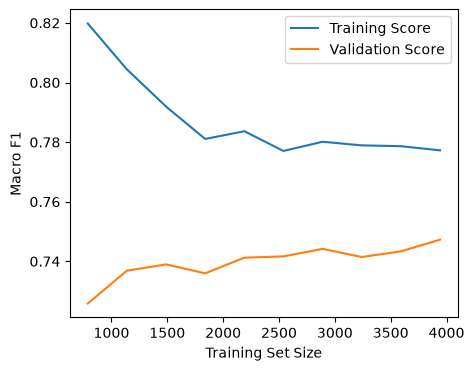

In [273]:
# Run learning curve 
train_sizes, train_scores, test_scores = learning_curve(
    xgb_model_tuned, X_train, y_train, cv=5, 
    scoring='f1_macro', train_sizes=np.linspace(0.2, 1.0, 10)
)

# Plot the convergence lines
plt.figure(figsize=(5, 4))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training Score")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Validation Score")
plt.xlabel("Training Set Size"); plt.ylabel("Macro F1"); plt.legend(); plt.show()


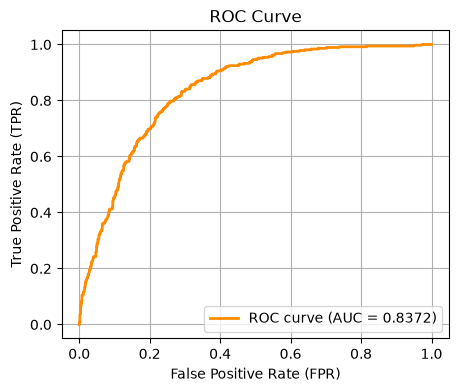

In [224]:
# Plot AUC-ROC curve

# Extract prob
probabilities = xgb_model_tuned.predict_proba(X_test)[:, 1]

# The roc_curve function calculates FPR and TPR for all thresholds.
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

# Calculate the AUC
roc_auc = auc(fpr, tpr)

# Plotting the ROC Curve
plt.figure(figsize=(5, 4))
# Plot the curve using matplotlib
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

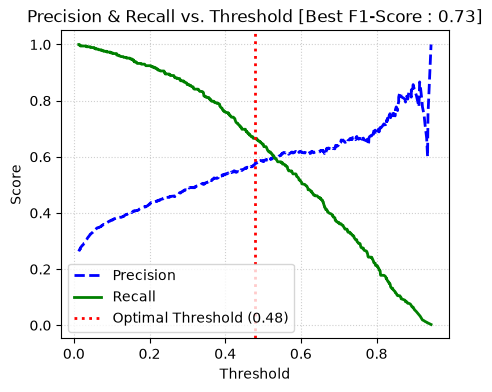

In [272]:
# Calculate precision and recall values across all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, probabilities)

# Best f1-score thrshold
best_macro_f1 = 0
best_threshold = 0.50

# Iterate through thresholds to find the peak performance point
for t in np.linspace(0.1, 0.9, 100):
    preds = (probabilities >= t).astype(int)
    score = f1_score(y_test, preds, average='macro')
    if score > best_macro_f1:
        best_macro_f1 = score
        best_threshold = t

# Plot Precision and Recall vs Threshold
plt.figure(figsize=(5, 4))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', lw=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', lw=2)

# Draw a vertical visual line at the mathematically optimal threshold
plt.axvline(x=best_threshold, color='red', linestyle=':', lw=2, 
            label=f'Optimal Threshold ({best_threshold:.2f})')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title(f'Precision & Recall vs. Threshold [Best F1-Score : {best_macro_f1:.2f}]')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


In [270]:
booster = xgb_model_tuned.get_booster()

# Feature importance
feature_importance = booster.get_score(importance_type = "gain")


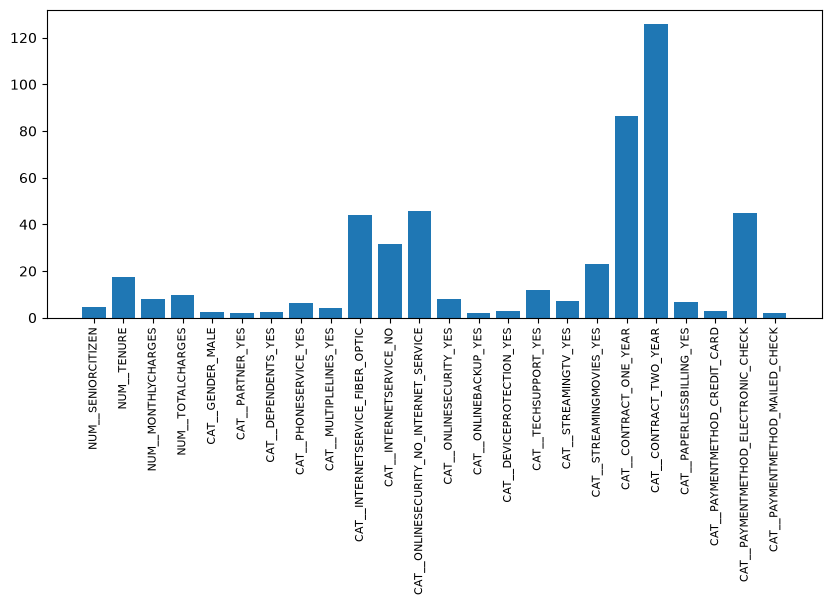

In [271]:
plt.figure(figsize = (10,4))
plt.bar(x=feature_importance.keys(),height = feature_importance.values())
plt.xticks(rotation = 90,fontsize = 8)
plt.show()

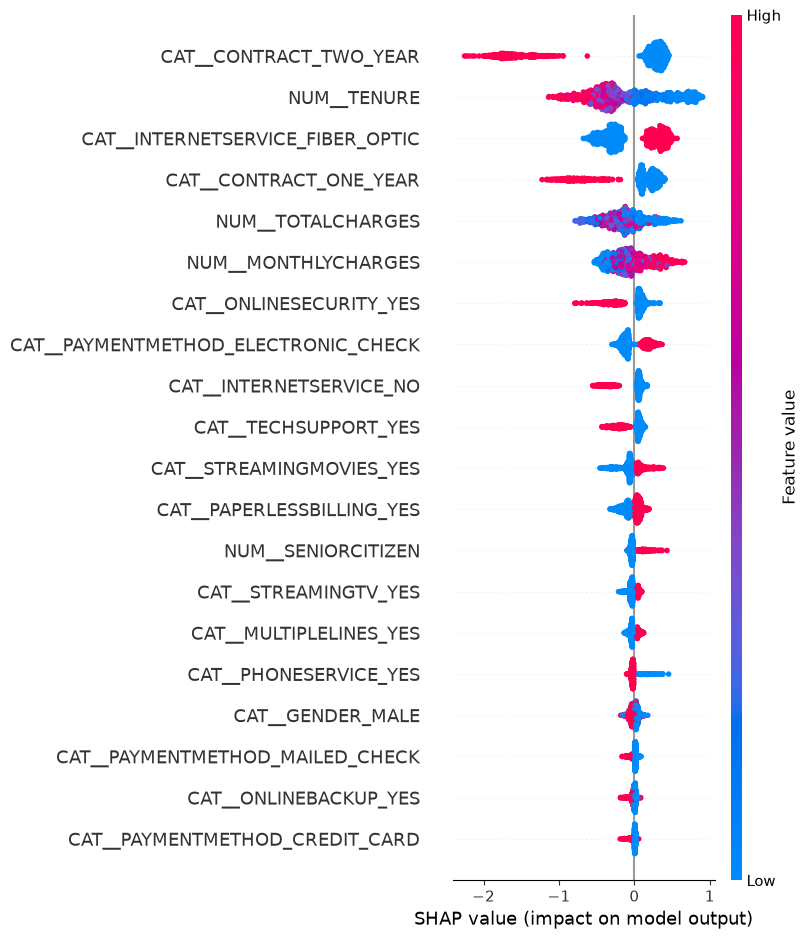

In [175]:
import shap

explainer = shap.TreeExplainer(xgb_model_tuned)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

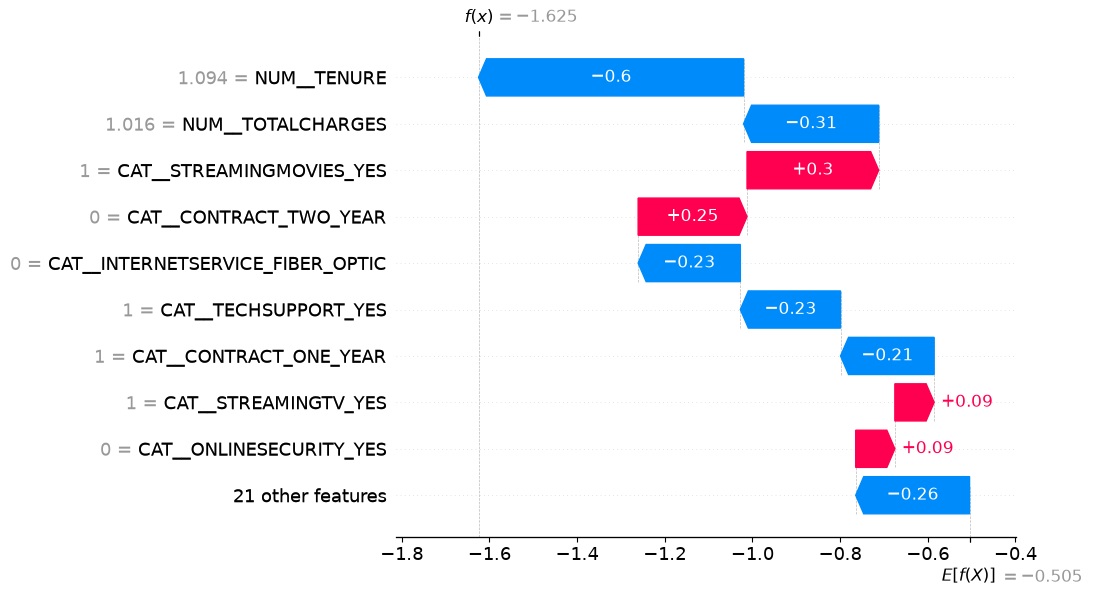

In [176]:
shap.waterfall_plot(shap_values[1])